# MLSR Binning Demo

This notebook uses the reusable `estimate_binning_scales` function from `binning.py`. It estimates the Freedman-Diaconis optimal bin width `h_fd` and Gaussian/RBF kernel length `lambda_opt` from a 1D scattering curve.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from binning import synthetic_scattering_data, estimate_binning_scales, rbf_gpr_predict

## Synthetic Data

The helper below creates a small noisy scattering curve so the example is fully reproducible.

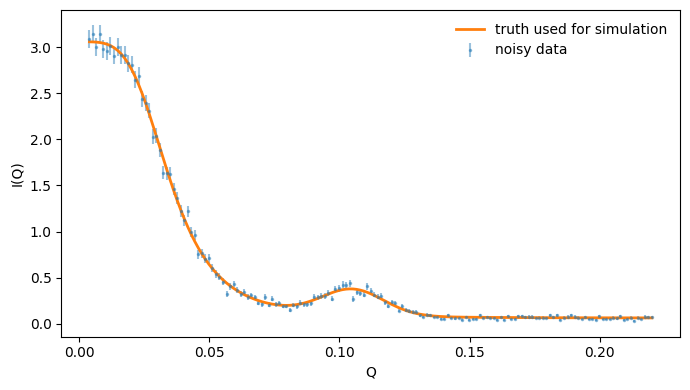

In [2]:
total_counts = 3.0e4
q, intensity, intensity_error, true_intensity = synthetic_scattering_data(
    n_points=161,
    total_counts=total_counts,
    seed=7,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(q, intensity, yerr=intensity_error, fmt=".", ms=3, alpha=0.45, label="noisy data")
ax.plot(q, true_intensity, lw=2, label="truth used for simulation")
ax.set_xlabel("Q")
ax.set_ylabel("I(Q)")
# ax.set_yscale("log")
ax.legend(frameon=False)
fig.tight_layout()

## Estimate Best Bin Width and Kernel Size

In [3]:
result = estimate_binning_scales(
    q,
    intensity,
    total_counts=total_counts,
    intensity_error=intensity_error,
    window_frac=0.3,
    polyorder=3,
)

print(f"Median data bin width: {result.data_bin_width:.6e}")
print(f"Best Freedman-Diaconis optimal bin width h_fd: {result.h_fd:.6e}")
print(f"Best Gaussian/RBF kernel size lambda_opt: {result.lambda_opt:.6e}")
print()
print(f"alpha: {result.alpha:.6e}")
print(f"beta:  {result.beta:.6e}")
print(f"gamma: {result.gamma:.6e}")
print(f"chi:   {result.chi:.6e}")
print(f"Savitzky-Golay window used: {result.window_length}")

Median data bin width: 1.350000e-03
Best Freedman-Diaconis optimal bin width h_fd: 2.672378e-03
Best Gaussian/RBF kernel size lambda_opt: 3.216037e-03

alpha: 2.444920e-06
beta:  6.405325e+01
gamma: 5.011806e+05
chi:   8.870242e-02
Savitzky-Golay window used: 49


## GPR Reconstruction with Scaled Optimized Kernel

Use `lambda_opt` as the manuscript-derived RBF kernel size, or change `lambda_scale` below to inspect nearby choices. Smaller kernels can follow noisy fluctuations, while wider kernels increase curvature-induced bias from the underlying signal. The lower panel compares a local Gaussian-weighted counting-error estimate against `4 x` squared curvature bias. Both lower-panel curves are estimated from the sampled observation, so the same diagnostic can be used when ground truth is unavailable.

`total_counts` is distributed across the full Q range in proportion to intensity. Low-intensity regions therefore have fewer counts and larger relative error, even though their absolute intensity error can be smaller. Set `use_relative_error = True` below to show relative squared contributions instead of absolute MSE contributions.

At `lambda_scale = 1`, the integrated comparison is only approximate: `lambda_opt` comes from the manuscript's asymptotic average MSE model, while the plotted counting error is a finite-data local estimate. The ground truth is shown only in the upper panel to validate the synthetic example.

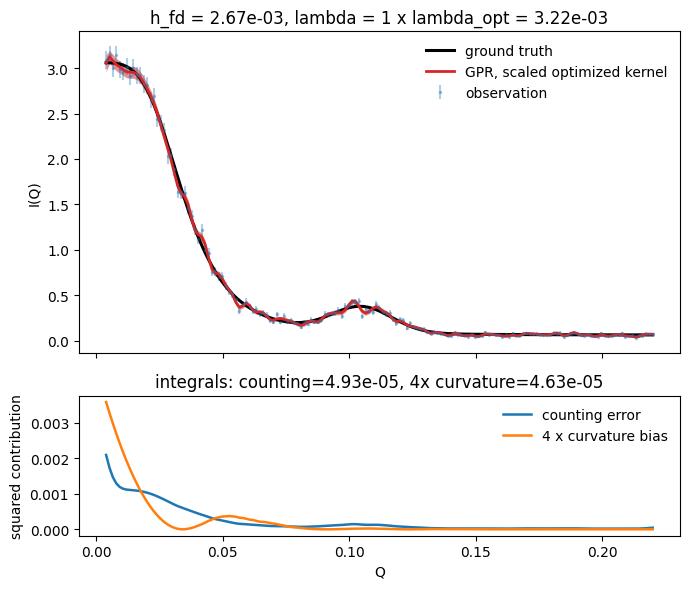

In [4]:
lambda_opt = result.lambda_opt
lambda_scale = 1.0  # Increase or decrease this to explore the noise-curvature trade-off.
use_relative_error = False  # Set True to emphasize larger relative noise at low intensity.
lambda_opt_scaled = lambda_opt * lambda_scale
observation_color = "tab:blue"
gpr_intensity, gpr_std = rbf_gpr_predict(
    q,
    intensity,
    intensity_error,
    q_predict=q,
    kernel_size=lambda_opt_scaled,
    return_std=True,
)

if result.used_savgol:
    from scipy.signal import savgol_filter

    sampled_second = savgol_filter(
        intensity,
        window_length=result.window_length,
        polyorder=result.polyorder,
        deriv=2,
        delta=result.data_bin_width,
        mode="interp",
    )
else:
    sampled_first = np.gradient(intensity, q, edge_order=2)
    sampled_second = np.gradient(sampled_first, q, edge_order=2)

curvature_bias = 0.5 * lambda_opt_scaled**2 * sampled_second
kernel_weights = np.exp(-0.5 * ((q[:, None] - q[None, :]) / lambda_opt_scaled) ** 2)
kernel_weights = kernel_weights / kernel_weights.sum(axis=1, keepdims=True)
counting_error_sq = (kernel_weights**2) @ (intensity_error**2)
curvature_bias_sq_scaled = 4.0 * curvature_bias**2
diagnostic_ylabel = "squared contribution"
if use_relative_error:
    reference_intensity = np.maximum(np.abs(gpr_intensity), np.finfo(float).eps)
    counting_error_sq = counting_error_sq / reference_intensity**2
    curvature_bias_sq_scaled = curvature_bias_sq_scaled / reference_intensity**2
    diagnostic_ylabel = "relative squared contribution"
counting_error_integral = np.trapezoid(counting_error_sq, q)
curvature_bias_integral = np.trapezoid(curvature_bias_sq_scaled, q)

fig, (ax, ax_err) = plt.subplots(
    2,
    1,
    figsize=(7, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [2.3, 1.0]},
)
ax.fill_between(
    q,
    gpr_intensity - gpr_std,
    gpr_intensity + gpr_std,
    color="tab:red",
    alpha=0.5,
    linewidth=0,
    # label="GPR +/- 1 sigma",
)
ax.errorbar(
    q,
    intensity,
    yerr=intensity_error,
    fmt=".",
    ms=3,
    color=observation_color,
    alpha=0.35,
    label="observation",
)
ax.plot(q, true_intensity, lw=2.2, color="black", label="ground truth")
ax.plot(q, gpr_intensity, lw=2.0, color="tab:red", label="GPR, scaled optimized kernel")
ax.set_ylabel("I(Q)")
# ax.set_yscale("log")
ax.set_title(f"h_fd = {result.h_fd:.2e}, lambda = {lambda_scale:.2g} x lambda_opt = {lambda_opt_scaled:.2e}")
ax.legend(frameon=False)

ax_err.plot(q, counting_error_sq, color=observation_color, lw=1.8, label="counting error")
ax_err.plot(
    q,
    curvature_bias_sq_scaled,
    color="tab:orange",
    lw=1.8,
    label="4 x curvature bias",
)
ax_err.set_xlabel("Q")
ax_err.set_ylabel(diagnostic_ylabel)
ax_err.set_title(
    "integrals: "
    f"counting={counting_error_integral:.2e}, "
    f"4x curvature={curvature_bias_integral:.2e}"
)
ax_err.legend(frameon=False)
fig.tight_layout()

## Use Your Own Data

Replace `q_user`, `i_user`, and either `total_counts_user` or `i_err_user` with arrays from your measurement.

In [5]:
# q_user = ...
# i_user = ...
# total_counts_user = ...
# i_err_user = ...

# estimate = estimate_binning_scales(
#     q_user,
#     i_user,
#     total_counts=total_counts_user,
#     # intensity_error=i_err_user,  # needed only if total_counts is omitted
# )
# estimate.h_fd, estimate.lambda_opt